# F1-SIS: Circuit-Aware SC Probability Model

**Option D — Location-Stable Circuit Features**

---

## Key design decisions in this notebook

### 1. `Location` over `RaceName`

Race names change for the **same physical track**:

| Race Name | Physical Circuit |
|-----------|------------------|
| Austrian GP + Styrian GP | Red Bull Ring |
| British GP + 70th Anniversary GP | Silverstone |
| Brazilian GP + Sao Paulo GP | Interlagos |
| Mexican GP + Mexico City GP | Hermanos Rodriguez |

Using `RaceName` would treat these as different circuits, losing statistical power.
The CSV already contains a `Location` column (physical venue). We use that.

### 2. Option D circuit feature set

| Feature | Captures |
|---------|----------|
| `circuit_id` (encoded Location) | Full circuit identity for model to learn any pattern |
| `circuit_progress_sc_rate` | Shrunken circuit x race-progress SC probability |
| `circuit_avg_sc_per_race` | Historical avg SC events per race at this venue |
| `circuit_vsc_rate` | Historical VSC rate |
| `is_street_circuit` | Domain knowledge flag |

### 3. XGBoost categorical handling

XGBoost's `enable_categorical=True` requires all category codes in val/test
to exist in train. Instead we label-encode Location on the full dataset
(encoding identity is not leakage) and pass integer `circuit_id` as a regular
feature — the tree still learns circuit-specific splits.


---

## 1. Imports & Configuration


In [60]:
import os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xgboost as xgb
from sklearn.isotonic import IsotonicRegression

class Unscaler:
    def __init__(self, w): self.w = w
    def predict(self, raw):
        import numpy as np
        r = np.array(raw, dtype=float)
        return r / (r + (1.0 - r) * self.w + 1e-9)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    brier_score_loss, average_precision_score,
    roc_auc_score, log_loss
)
from sklearn.calibration import calibration_curve

try:
    import catboost as cb
    CATBOOST_AVAILABLE = True
    print('CatBoost:', cb.__version__)
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost not available.')

print('XGBoost:', xgb.__version__)


CatBoost: 1.2.10
XGBoost: 3.4.0


In [61]:
DATA_DIR      = os.path.join('data_fastf1_v1', 'laps')
MODEL_DIR     = 'models'
HORIZONS      = [3, 5, 10]
MAX_HORIZON   = max(HORIZONS)
RANDOM_SEED   = 42

TRAIN_SEASONS = [2018, 2019, 2020, 2021, 2022, 2023]
VAL_SEASONS   = [2024]
TEST_SEASONS  = [2025]

PROGRESS_BINS   = [0, 0.01, 0.20, 0.40, 0.60, 0.80, 1.01]
PROGRESS_LABELS = ['Lap1', '2-20', '20-40', '40-60', '60-80', '80-100']
SHRINKAGE_K     = 20

os.makedirs(MODEL_DIR, exist_ok=True)
print('Config ready.')


Config ready.


---

## 2. Street Circuit Classification by Location

Defined by physical circuit location — stable even when race names change.


In [62]:
# Street circuits classified by physical Location value in the CSV
# A street circuit uses temporary barriers on public roads / has very limited run-off
STREET_LOCATIONS = {
    'monaco',
    'baku',          # Azerbaijan GP
    'marina bay',    # Singapore
    'jeddah',        # Saudi Arabia
    'miami',
    'las vegas',
    'albert park',   # Melbourne - semi-street characteristics
    'losail',        # Qatar - treated as semi-street (limited run-off)
}

def is_street_circuit(location_str):
    loc = str(location_str).lower().strip()
    return int(any(kw in loc for kw in STREET_LOCATIONS))


# Preview with some known locations
test_locations = ['Monaco', 'Baku', 'Silverstone', 'Marina Bay',
                  'Spa-Francorchamps', 'Jeddah', 'Yas Island', 'Monza']
for loc in test_locations:
    print(f'  {loc:<25} -> street={is_street_circuit(loc)}')


  Monaco                    -> street=1
  Baku                      -> street=1
  Silverstone               -> street=0
  Marina Bay                -> street=1
  Spa-Francorchamps         -> street=0
  Jeddah                    -> street=1
  Yas Island                -> street=0
  Monza                     -> street=0


---

## 3. Data Loading & Race-Level Aggregation

The `Location` column (physical circuit) is preserved alongside `RaceName`.


In [63]:
TS_SC  = '4'
TS_VSC = '6'
TS_VSC_ENDING = '7'
TS_YELLOW = '2'


def decode_track_status(s):
    s = s.astype(str).str.strip()
    return pd.DataFrame({
        'sc_active' : s.str.contains(TS_SC,         na=False),
        'vsc_active': s.str.contains(TS_VSC,        na=False),
        'vsc_ending': s.str.contains(TS_VSC_ENDING, na=False),
        'yellow'    : s.str.contains(TS_YELLOW,     na=False),
    })


def load_and_aggregate(data_dir=DATA_DIR):
    frames = []
    for season_dir in sorted(Path(data_dir).iterdir()):
        if not season_dir.is_dir(): continue
        try: year = int(season_dir.name)
        except ValueError: continue
        for f in sorted(season_dir.glob('*.csv')):
            try:
                df = pd.read_csv(f, low_memory=False)
                df['Year']     = year
                df['RaceName'] = f.stem
                df['race_id']  = f'{year}_{f.stem}'
                frames.append(df)
            except Exception as e:
                print(f'  WARNING {f.name}: {e}')
    df_all = pd.concat(frames, ignore_index=True)
    print(f'Raw rows: {len(df_all):,} from {len(frames)} races')

    # Check Location column
    if 'Location' not in df_all.columns:
        print('WARNING: Location column not found - falling back to RaceName')
        df_all['Location'] = df_all.get('RaceName', 'Unknown')
    else:
        print(f'Location values (sample): {df_all["Location"].value_counts().head(5).index.tolist()}')

    # Decode status
    decoded = decode_track_status(df_all['TrackStatus'])
    for col in decoded.columns:
        df_all[col] = decoded[col]

    # Numeric casts
    df_all['LapNumber'] = pd.to_numeric(df_all['LapNumber'], errors='coerce')
    for col in ['LapTimeSeconds','TyreLife','AirTemp','TrackTemp','Humidity', 'Sector1TimeSeconds', 'Sector2TimeSeconds', 'Sector3TimeSeconds', 'IntervalToPositionAheadSeconds']:
        if col in df_all.columns:
            df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
    if 'Rainfall' in df_all.columns:
        df_all['Rainfall'] = df_all['Rainfall'].astype(str).str.lower().isin(['true','1','yes'])
    df_all['pitted'] = df_all['PitInTime'].notna() if 'PitInTime' in df_all.columns else False

    # Initialize new columns with NaN if missing
    for col in ['Sector1TimeSeconds', 'Sector2TimeSeconds', 'Sector3TimeSeconds', 'IntervalToPositionAheadSeconds']:
        if col not in df_all.columns:
            df_all[col] = np.nan

    df_all = df_all.dropna(subset=['LapNumber','race_id'])
    df_all['LapNumber'] = df_all['LapNumber'].astype(int)

    # Aggregate to race-lap level — keep Location as mode (same for all drivers)
    grp = df_all.groupby(['race_id','Year','RaceName','LapNumber'])
    agg = grp.agg(
        sc_active    =('sc_active',      'any'),
        vsc_active   =('vsc_active',     'any'),
        vsc_ending   =('vsc_ending',     'any'),
        yellow       =('yellow',         'any'),
        location     =('Location',       lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'),
        n_cars       =('Driver',         'nunique'),
        lap_time_med =('LapTimeSeconds', 'median'),
        lap_time_std =('LapTimeSeconds', 'std'),
        tyre_age_med =('TyreLife',        'median'),
        tyre_age_max =('TyreLife',        'max'),
        air_temp     =('AirTemp',         'median'),
        track_temp   =('TrackTemp',       'median'),
        humidity     =('Humidity',        'median'),
        rainfall     =('Rainfall',        'any'),
        total_pits   =('pitted',          'sum'),
        sector1_med  =('Sector1TimeSeconds', 'median'),
        sector2_med  =('Sector2TimeSeconds', 'median'),
        sector3_med  =('Sector3TimeSeconds', 'median'),
        drs_density  =('IntervalToPositionAheadSeconds', lambda x: (x.dropna() < 1.0).mean() if len(x.dropna()) > 0 else 0.0),
    ).reset_index()

    max_laps = df_all.groupby('race_id')['LapNumber'].max().rename('total_laps').reset_index()
    agg = agg.merge(max_laps, on='race_id', how='left')
    agg['race_progress']  = agg['LapNumber'] / agg['total_laps']
    agg['laps_remaining'] = agg['total_laps'] - agg['LapNumber']
    agg = agg.sort_values(['race_id','LapNumber'])
    agg['peak_cars']   = agg.groupby('race_id')['n_cars'].transform('cummax')
    agg['retirements'] = (agg['peak_cars'] - agg['n_cars']).clip(lower=0)

    # Street circuit flag uses Location
    agg['is_street_circuit'] = agg['location'].apply(is_street_circuit)
    agg['is_lap_1'] = (agg['LapNumber'] == 1).astype(int)

    print(f'Race-level rows: {len(agg):,}')
    print(f'Unique locations: {agg["location"].nunique()}')
    print('Sample location -> racename mapping:')
    print(agg[['location','RaceName']].drop_duplicates().head(10).to_string(index=False))
    return agg


df_laps = load_and_aggregate()


Raw rows: 188,482 from 172 races
Location values (sample): ['Spielberg', 'Budapest', 'Sakhir', 'Barcelona', 'Mexico City']
Race-level rows: 10,317
Unique locations: 35
Sample location -> racename mapping:
         location              RaceName
       Yas Marina  Abu_Dhabi_Grand_Prix
        Melbourne Australian_Grand_Prix
        Spielberg   Austrian_Grand_Prix
             Baku Azerbaijan_Grand_Prix
           Sakhir    Bahrain_Grand_Prix
Spa-Francorchamps    Belgian_Grand_Prix
        São Paulo  Brazilian_Grand_Prix
      Silverstone    British_Grand_Prix
         Montréal   Canadian_Grand_Prix
         Shanghai    Chinese_Grand_Prix


---

## 4. Event Detection & Target Construction


In [64]:
def detect_events(df):
    df = df.sort_values(['race_id','LapNumber']).copy()
    sc_prev = df.groupby('race_id')['sc_active'].shift(1, fill_value=False)
    df['sc_started']       = ((~sc_prev) & df['sc_active']).astype(int)
    df['vsc_truly_active'] = df['vsc_active'] & ~df['vsc_ending']
    vsc_prev = df.groupby('race_id')['vsc_truly_active'].shift(1, fill_value=False)
    df['vsc_started'] = ((~vsc_prev) & df['vsc_truly_active']).astype(int)
    return df


def build_targets(df, horizons=HORIZONS):
    rows = []
    for race_id, grp in df.sort_values(['race_id','LapNumber']).groupby('race_id'):
        grp       = grp.sort_values('LapNumber').reset_index(drop=True)
        sc_starts = grp.loc[grp['sc_started']==1, 'LapNumber'].values
        total     = grp['total_laps'].iloc[0]
        for _, row in grp.iterrows():
            if row['sc_active']: continue
            t      = row['LapNumber']
            future = sc_starts[sc_starts > t]
            next_sc   = future[0]    if len(future) else np.nan
            laps_until = next_sc - t if not np.isnan(next_sc) else np.nan
            rec = {'race_id': race_id, 'LapNumber': t,
                   'next_sc_lap': next_sc, 'laps_until_next_sc': laps_until}
            for n in horizons:
                if t + n > total:
                    rec[f'SC_next_{n}'] = np.nan
                elif not np.isnan(laps_until) and laps_until <= n:
                    rec[f'SC_next_{n}'] = 1
                else:
                    rec[f'SC_next_{n}'] = 0
            rows.append(rec)
    targets = pd.DataFrame(rows)
    print(f'Prediction points: {len(targets):,}')
    non_sc = (~df['sc_active']).sum()
    sc_ev  = df['sc_started'].sum()
    print(f'Global SC rate: {sc_ev}/{non_sc} = {sc_ev/non_sc:.4f}')
    return targets


df_laps  = detect_events(df_laps)
targets  = build_targets(df_laps)


Prediction points: 9,645
Global SC rate: 128/9645 = 0.0133


---

## 5. Circuit Features (Location-Based, Leakage-Safe)

All circuit statistics are computed from **training races only**,
then merged into validation and test sets.

The `circuit_id` label encoder is fitted on **all locations** (train + val + test)
because encoding identity is not leakage — we are not computing historical statistics,
just giving each physical circuit a stable integer index.


In [65]:
def build_circuit_features(df_laps, train_race_ids, shrinkage_k=SHRINKAGE_K):
    train    = df_laps[df_laps['race_id'].isin(train_race_ids)].copy()
    non_sc   = train[~train['sc_active']]

    global_sc_rate  = non_sc['sc_started'].sum()  / max(len(non_sc), 1)
    global_vsc_rate = non_sc['vsc_started'].sum() / max(len(non_sc), 1)
    print(f'Global SC rate  : {global_sc_rate:.4f}')
    print(f'Global VSC rate : {global_vsc_rate:.4f}')

    # ── Per-location SC rate (shrunken) ────────────────────────────────────
    by_loc = (
        non_sc.groupby('location')
        .agg(sc_ev=('sc_started','sum'),
             n_laps=('sc_started','count'),
             n_races=('race_id','nunique'))
        .reset_index()
    )
    by_loc['circuit_sc_rate'] = (
        (by_loc['sc_ev'] + shrinkage_k * global_sc_rate) /
        (by_loc['n_laps'] + shrinkage_k)
    )
    by_loc['circuit_avg_sc_per_race'] = (
        by_loc['sc_ev'] / by_loc['n_races'].clip(lower=1)
    )

    # ── Per-location VSC rate (shrunken) ───────────────────────────────────
    by_loc_vsc = (
        non_sc.groupby('location')
        .agg(vsc_ev=('vsc_started','sum'), n_laps_v=('vsc_started','count'))
        .reset_index()
    )
    by_loc_vsc['circuit_vsc_rate'] = (
        (by_loc_vsc['vsc_ev'] + shrinkage_k * global_vsc_rate) /
        (by_loc_vsc['n_laps_v'] + shrinkage_k)
    )

    # ── Circuit x race-progress shrunken rate ──────────────────────────────
    non_sc = non_sc.copy()
    non_sc['progress_bin'] = pd.cut(
        non_sc['race_progress'],
        bins=PROGRESS_BINS, labels=PROGRESS_LABELS, right=False
    )
    global_prog = (
        non_sc.groupby('progress_bin', observed=True)
        .agg(sc_ev=('sc_started','sum'), n=('sc_started','count'))
        .assign(global_prog_rate=lambda x: x['sc_ev']/x['n'])
        .reset_index()
    )
    circ_prog = (
        non_sc.groupby(['location','progress_bin'], observed=True)
        .agg(sc_ev=('sc_started','sum'), n_laps=('sc_started','count'))
        .reset_index()
        .merge(global_prog[['progress_bin','global_prog_rate']], on='progress_bin', how='left')
    )
    circ_prog['circuit_progress_sc_rate'] = (
        (circ_prog['sc_ev'] + shrinkage_k * circ_prog['global_prog_rate']) /
        (circ_prog['n_laps'] + shrinkage_k)
    )

    # ── Combine static features ────────────────────────────────────────────
    circ_all = by_loc[['location','circuit_sc_rate','circuit_avg_sc_per_race']]
    circ_all = circ_all.merge(by_loc_vsc[['location','circuit_vsc_rate']], on='location', how='left')

    print(f'Circuit features for {len(circ_all)} unique locations (training):')
    print(
        circ_all.sort_values('circuit_sc_rate', ascending=False)
        .head(12).to_string(index=False)
    )
    return circ_all, circ_prog, global_sc_rate


train_race_ids = df_laps.loc[df_laps['Year'].isin(TRAIN_SEASONS), 'race_id'].unique()
circ_features, circ_prog_features, global_sc_rate = build_circuit_features(df_laps, train_race_ids)


Global SC rate  : 0.0000
Global VSC rate : 0.0074
Circuit features for 34 unique locations (training):
    location  circuit_sc_rate  circuit_avg_sc_per_race  circuit_vsc_rate
      Austin              0.0                      0.0          0.003943
        Baku              0.0                      0.0          0.012743
   Barcelona              0.0                      0.0          0.002890
    Budapest              0.0                      0.0          0.007186
  Hockenheim              0.0                      0.0          0.017459
       Imola              0.0                      0.0          0.006169
    Istanbul              0.0                      0.0          0.008438
      Jeddah              0.0                      0.0          0.020306
   Las Vegas              0.0                      0.0          0.018214
Le Castellet              0.0                      0.0          0.005123
      Lusail              0.0                      0.0          0.008827
  Marina Bay         

In [66]:
def build_label_encoder(df_laps):
    """
    Fit LabelEncoder on ALL locations (all seasons).
    This is not leakage: we are only encoding circuit identity,
    not computing statistics from future races.
    """
    all_locations = df_laps['location'].fillna('Unknown').unique()
    le = LabelEncoder()
    le.fit(all_locations)
    print(f'LabelEncoder fitted on {len(all_locations)} unique locations.')
    print('Classes:', list(le.classes_))
    return le


circuit_le = build_label_encoder(df_laps)


LabelEncoder fitted on 35 unique locations.
Classes: ['Austin', 'Baku', 'Barcelona', 'Budapest', 'Hockenheim', 'Imola', 'Istanbul', 'Jeddah', 'Las Vegas', 'Le Castellet', 'Lusail', 'Marina Bay', 'Melbourne', 'Mexico City', 'Miami', 'Miami Gardens', 'Monaco', 'Monte Carlo', 'Montréal', 'Monza', 'Mugello', 'Nürburgring', 'Portimão', 'Sakhir', 'Shanghai', 'Silverstone', 'Singapore', 'Sochi', 'Spa-Francorchamps', 'Spielberg', 'Suzuka', 'São Paulo', 'Yas Island', 'Yas Marina', 'Zandvoort']


---

## 6. Full Feature Matrix


In [67]:
def build_features(df_laps, targets, circ_features, circ_prog_features,
                   circuit_le, global_sc_rate):
    df = df_laps.sort_values(['race_id','LapNumber']).copy()

    # ── Causal race-state features ─────────────────────────────────────────
    df['sc_count_cumul']  = df.groupby('race_id')['sc_started'].cumsum().shift(1, fill_value=0)
    df['vsc_count_cumul'] = df.groupby('race_id')['vsc_started'].cumsum().shift(1, fill_value=0)

    def laps_since(group, col):
        result, last = [], None
        for i in range(len(group)):
            if i > 0 and group.iloc[i-1][col] == 1:
                last = group.iloc[i-1]['LapNumber']
            result.append(group.iloc[i]['LapNumber'] - last if last is not None else 999)
        return result

    lsc, lvsc = [], []
    for _, grp in df.groupby('race_id'):
        g = grp.reset_index(drop=True)
        lsc.extend(laps_since(g, 'sc_started'))
        lvsc.extend(laps_since(g, 'vsc_started'))
    df['laps_since_sc']  = lsc
    df['laps_since_vsc'] = lvsc

    df['lap_time_roll3_std'] = (
        df.groupby('race_id')['lap_time_med']
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).std()).fillna(0)
    )
    df['pits_last3'] = (
        df.groupby('race_id')['total_pits']
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum()).fillna(0)
    )
    df['yellow_last5'] = (
        df.groupby('race_id')['yellow']
        .transform(lambda x: x.astype(int).shift(1).rolling(5, min_periods=1).sum()).fillna(0)
    )
    df['rainfall_flag'] = df['rainfall'].astype(int)
    for col in ['tyre_age_med','tyre_age_max','air_temp','track_temp','humidity',
                'lap_time_std','lap_time_med']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # ── Attach static circuit features ─────────────────────────────────────
    df = df.merge(circ_features, on='location', how='left')
    df['circuit_sc_rate']        = df['circuit_sc_rate'].fillna(global_sc_rate)
    df['circuit_vsc_rate']        = df['circuit_vsc_rate'].fillna(global_sc_rate)
    df['circuit_avg_sc_per_race'] = df['circuit_avg_sc_per_race'].fillna(
        circ_features['circuit_avg_sc_per_race'].mean())

    # ── Attach circuit x progress feature ─────────────────────────────────
    df['progress_bin'] = pd.cut(
        df['race_progress'], bins=PROGRESS_BINS, labels=PROGRESS_LABELS, right=False
    )
    df = df.merge(
        circ_prog_features[['location','progress_bin','circuit_progress_sc_rate']],
        on=['location','progress_bin'], how='left'
    )
    df['circuit_progress_sc_rate'] = df['circuit_progress_sc_rate'].fillna(
        df['circuit_sc_rate'])

    # ── circuit_id: integer encoding of physical location ─────────────────
    df['circuit_id'] = circuit_le.transform(
        df['location'].fillna('Unknown')
    )

    # ── Merge into targets ─────────────────────────────────────────────────
    keep = [
        'race_id','LapNumber','Year','RaceName','location',
        'race_progress','laps_remaining',
        'sc_count_cumul','vsc_count_cumul',
        'laps_since_sc','laps_since_vsc',
        'n_cars','retirements',
        'lap_time_med','lap_time_std','lap_time_roll3_std',
        'tyre_age_med','tyre_age_max',
        'total_pits','pits_last3','yellow_last5','rainfall_flag',
    'sector1_med','sector2_med','sector3_med','drs_density','is_lap_1',
        'is_street_circuit',
        'circuit_id','circuit_sc_rate','circuit_vsc_rate',
        'circuit_avg_sc_per_race','circuit_progress_sc_rate',
    ]
    avail  = [c for c in keep if c in df.columns]
    feat   = df[avail].copy()
    merged = targets.merge(feat, on=['race_id','LapNumber'], how='left')
    print(f'Feature matrix: {merged.shape}')
    return merged


feature_df = build_features(
    df_laps, targets, circ_features, circ_prog_features, circuit_le, global_sc_rate
)
print('Circuit feature preview:')
print(
    feature_df[['location','circuit_id','circuit_sc_rate',
                 'circuit_progress_sc_rate','is_street_circuit']]
    .drop_duplicates('location').sort_values('circuit_sc_rate', ascending=False)
    .head(10).to_string(index=False)
)


Feature matrix: (9645, 38)
Circuit feature preview:
         location  circuit_id  circuit_sc_rate  circuit_progress_sc_rate  is_street_circuit
       Yas Marina          33              0.0                       0.0                  0
        Melbourne          12              0.0                       0.0                  0
        Spielberg          29              0.0                       0.0                  0
             Baku           1              0.0                       0.0                  1
           Sakhir          23              0.0                       0.0                  0
Spa-Francorchamps          28              0.0                       0.0                  0
        São Paulo          31              0.0                       0.0                  0
      Silverstone          25              0.0                       0.0                  0
         Montréal          18              0.0                       0.0                  0
         Shanghai          2

---

## 7. Circuit SC Rate Visualization


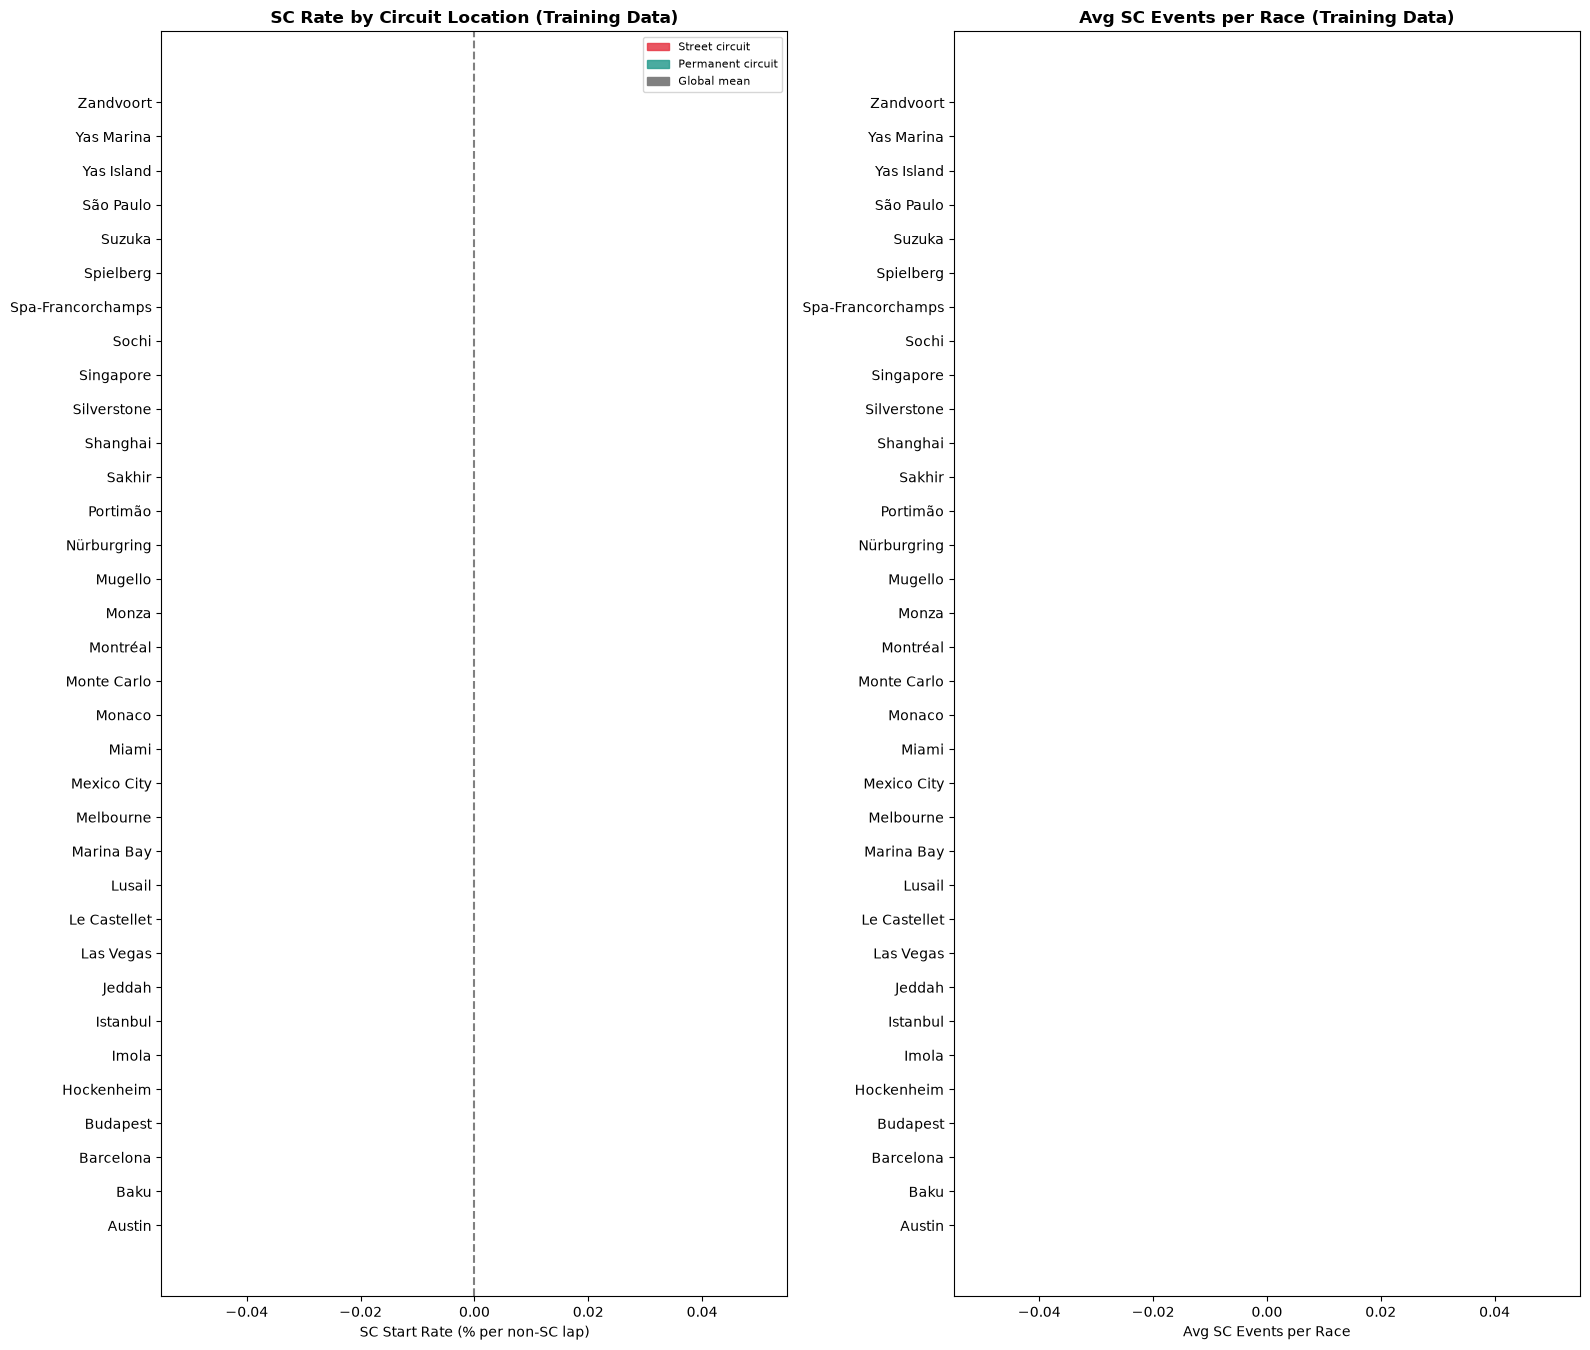

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(circ_features)*0.4)))

# Left: SC rate per location
circ_sorted = circ_features.sort_values('circuit_sc_rate', ascending=True)
street_mask = circ_sorted['location'].apply(is_street_circuit).astype(bool)
bar_colors  = ['#E63946' if s else '#2A9D8F' for s in street_mask]

axes[0].barh(circ_sorted['location'], circ_sorted['circuit_sc_rate']*100,
             color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].axvline(global_sc_rate*100, color='gray', linestyle='--',
                label=f'Global mean ({global_sc_rate*100:.2f}%)')
red_p  = mpatches.Patch(color='#E63946', alpha=0.85, label='Street circuit')
grn_p  = mpatches.Patch(color='#2A9D8F', alpha=0.85, label='Permanent circuit')
axes[0].legend(handles=[red_p, grn_p, mpatches.Patch(color='gray', label='Global mean')],
               fontsize=8)
axes[0].set_xlabel('SC Start Rate (% per non-SC lap)')
axes[0].set_title('SC Rate by Circuit Location (Training Data)', fontweight='bold')

# Right: avg SC events per race
circ_sorted2 = circ_features.sort_values('circuit_avg_sc_per_race', ascending=True)
street_mask2 = circ_sorted2['location'].apply(is_street_circuit).astype(bool)
bar_colors2  = ['#E63946' if s else '#F4A261' for s in street_mask2]
axes[1].barh(circ_sorted2['location'], circ_sorted2['circuit_avg_sc_per_race'],
             color=bar_colors2, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Avg SC Events per Race')
axes[1].set_title('Avg SC Events per Race (Training Data)', fontweight='bold')

plt.tight_layout()
plt.show()


---

## 8. Circuit x Race-Progress SC Rate Heatmap


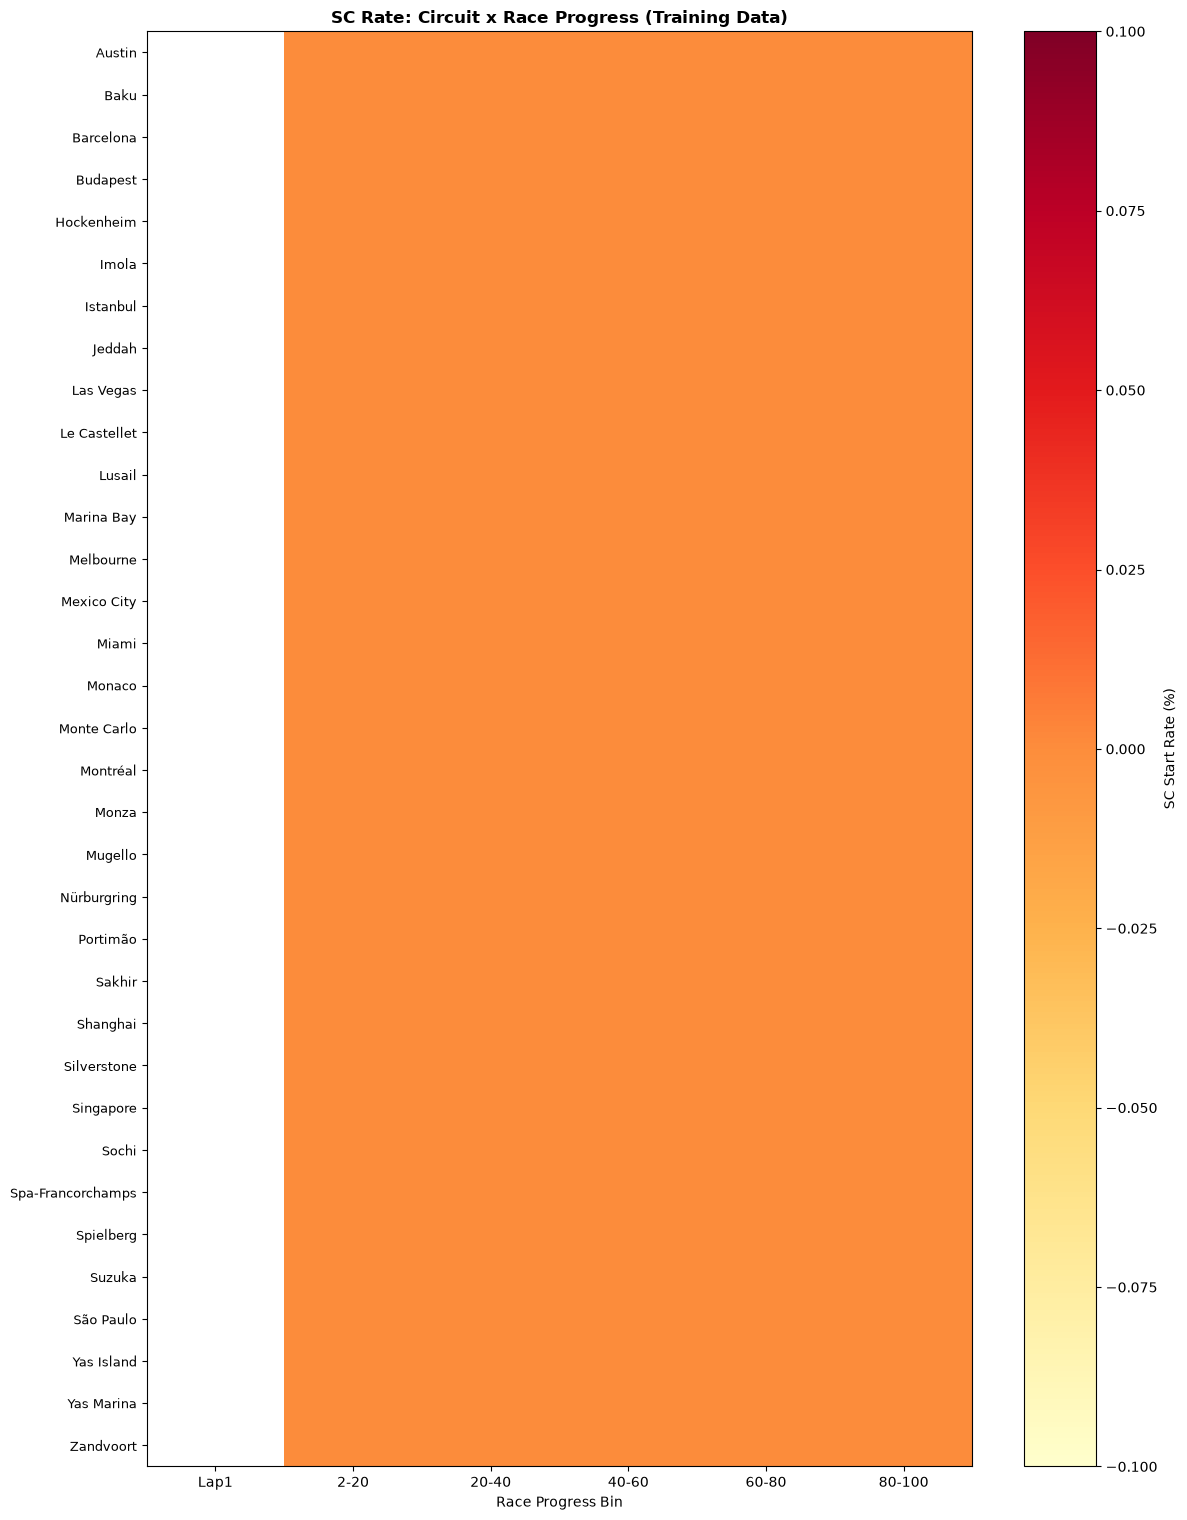

In [69]:
# Pivot to heatmap: locations x progress bins
pivot = circ_prog_features.pivot(
    index='location', columns='progress_bin', values='circuit_progress_sc_rate'
)
pivot = pivot.reindex(columns=PROGRESS_LABELS)
pivot = pivot.sort_values('20-40', ascending=False)  # sort by mid-race rate

fig, ax = plt.subplots(figsize=(12, max(5, len(pivot)*0.45)))
im = ax.imshow(pivot.values * 100, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(len(PROGRESS_LABELS)))
ax.set_xticklabels(PROGRESS_LABELS, fontsize=10)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=9)
plt.colorbar(im, ax=ax, label='SC Start Rate (%)')
ax.set_title('SC Rate: Circuit x Race Progress (Training Data)', fontweight='bold')
ax.set_xlabel('Race Progress Bin')
plt.tight_layout()
plt.show()


---

## 9. Chronological Split & Feature Sets


In [70]:
train_df = feature_df[feature_df['Year'].isin(TRAIN_SEASONS)].copy()
val_df   = feature_df[feature_df['Year'].isin(VAL_SEASONS)].copy()
test_df  = feature_df[feature_df['Year'].isin(TEST_SEASONS)].copy()

print(f'Train: {len(train_df):,} rows | {train_df["race_id"].nunique()} races')
print(f'Val  : {len(val_df):,} rows   | {val_df["race_id"].nunique()} races')
print(f'Test : {len(test_df):,} rows   | {test_df["race_id"].nunique()} races')

BASE_FEATURES = [
    'race_progress','laps_remaining',
    'sc_count_cumul','vsc_count_cumul',
    'laps_since_sc','laps_since_vsc',
    'n_cars','retirements',
    'lap_time_med','lap_time_std','lap_time_roll3_std',
    'tyre_age_med','tyre_age_max',
    'total_pits','pits_last3','yellow_last5','rainfall_flag',
    'sector1_med','sector2_med','sector3_med','drs_density','is_lap_1',
]

CIRCUIT_FEATURES = BASE_FEATURES + [
    'is_street_circuit',
    'circuit_id',                  # integer-encoded Location (stable across renames)
    'circuit_sc_rate',             # shrunken historical SC rate at this location
    'circuit_vsc_rate',
    'circuit_avg_sc_per_race',
    'circuit_progress_sc_rate',    # circuit x race-progress Heilmeier-style rate
]

print(f'Base features    : {len(BASE_FEATURES)}')
print(f'Circuit features : {len(CIRCUIT_FEATURES)}')
print(f'Circuit additions: {[f for f in CIRCUIT_FEATURES if f not in BASE_FEATURES]}')


Train: 6,915 rows | 124 races
Val  : 1,379 rows   | 24 races
Test : 1,351 rows   | 24 races
Base features    : 22
Circuit features : 28
Circuit additions: ['is_street_circuit', 'circuit_id', 'circuit_sc_rate', 'circuit_vsc_rate', 'circuit_avg_sc_per_race', 'circuit_progress_sc_rate']


---

## 10. Train XGBoost: Base vs Circuit-Aware

**Key fix:** `circuit_id` is a plain integer feature — no `enable_categorical=True`.
XGBoost decision trees split on integer features naturally (finding the optimal
threshold / set of circuits to split on). This avoids the categorical-unseen-value error
while still giving the model full access to the circuit signal.


In [71]:
def get_XY(df, horizon, features):
    col   = f'SC_next_{horizon}'
    sub   = df.dropna(subset=[col]).copy()
    avail = [f for f in features if f in sub.columns]
    X     = sub[avail].fillna(0)
    y     = sub[col].astype(int)
    return X, y, avail


def train_xgb(train_df, val_df, horizon, features, label='model'):
    X_tr, y_tr, feats = get_XY(train_df, horizon, features)
    X_va, y_va, _     = get_XY(val_df,   horizon, features)

    if y_tr.sum() == 0:
        print(f'  Horizon {horizon}: no events in training, skipping.')
        return None, None, None

    pos_w = float(y_tr.value_counts().get(0,1)) / max(float(y_tr.value_counts().get(1,1)), 1)

    model = xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        scale_pos_weight=pos_w, max_delta_step=5, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=RANDOM_SEED,
        tree_method='hist', verbosity=0,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    raw   = model.predict_proba(X_va)[:, 1]
    cal   = Unscaler(pos_w)
    brier = brier_score_loss(y_va, cal.predict(raw))
    prauc = average_precision_score(y_va, raw)
    return model, cal, {'brier': brier, 'prauc': prauc, 'feats': feats}


models_base, cals_base, metrics_base = {}, {}, {}
models_circ, cals_circ, metrics_circ = {}, {}, {}

print('=== Base Model (no circuit features) ===')
for n in HORIZONS:
    m, c, met = train_xgb(train_df, val_df, n, BASE_FEATURES)
    if m:
        models_base[n], cals_base[n], metrics_base[n] = m, c, met
        print(f'  n={n:>2}: Brier={met["brier"]:.4f}  PR-AUC={met["prauc"]:.4f}')

print()
print('=== Circuit-Aware Model (Option D, Location-based) ===')
for n in HORIZONS:
    m, c, met = train_xgb(train_df, val_df, n, CIRCUIT_FEATURES)
    if m:
        models_circ[n], cals_circ[n], metrics_circ[n] = m, c, met
        print(f'  n={n:>2}: Brier={met["brier"]:.4f}  PR-AUC={met["prauc"]:.4f}')


=== Base Model (no circuit features) ===
  n= 3: Brier=0.0202  PR-AUC=0.0193
  n= 5: Brier=0.0356  PR-AUC=0.0336
  n=10: Brier=0.0777  PR-AUC=0.0709

=== Circuit-Aware Model (Option D, Location-based) ===
  n= 3: Brier=0.0202  PR-AUC=0.0184
  n= 5: Brier=0.0391  PR-AUC=0.0310
  n=10: Brier=0.0899  PR-AUC=0.0573


---

## 11. CatBoost with Native Location Categorical

CatBoost handles raw string categoricals natively — we pass `location` directly.
It learns ordered/unordered category statistics internally, which is particularly
effective for high-cardinality categorical features like circuit identity.


In [72]:
if CATBOOST_AVAILABLE:
    CATB_FEATURES = BASE_FEATURES + [
        'is_street_circuit',
        'location',                    # raw string — CatBoost handles natively
        'circuit_sc_rate',
        'circuit_vsc_rate',
        'circuit_avg_sc_per_race',
        'circuit_progress_sc_rate',
    ]
    models_catb, cals_catb, metrics_catb = {}, {}, {}

    for n in HORIZONS:
        col    = f'SC_next_{n}'
        sub_tr = train_df.dropna(subset=[col]).copy()
        sub_va = val_df.dropna(subset=[col]).copy()
        avail  = [f for f in CATB_FEATURES if f in sub_tr.columns]

        X_tr, X_va = sub_tr[avail].copy(), sub_va[avail].copy()
        y_tr = sub_tr[col].astype(int)
        y_va = sub_va[col].astype(int)

        num_cols = [f for f in avail if f != 'location']
        X_tr[num_cols] = X_tr[num_cols].fillna(0)
        X_va[num_cols] = X_va[num_cols].fillna(0)
        X_tr['location'] = X_tr['location'].fillna('Unknown').astype(str)
        X_va['location'] = X_va['location'].fillna('Unknown').astype(str)

        cat_idx = [avail.index('location')]
        pos_w   = float(y_tr.value_counts().get(0,1)) / max(float(y_tr.value_counts().get(1,1)),1)

        model = cb.CatBoostClassifier(
            iterations=400, depth=4, learning_rate=0.05,
            scale_pos_weight=pos_w, random_seed=RANDOM_SEED,
            verbose=0, eval_metric='Logloss'
        )
        model.fit(X_tr, y_tr, cat_features=cat_idx, eval_set=(X_va, y_va))

        raw   = model.predict_proba(X_va)[:, 1]
        cal   = Unscaler(pos_w)
        brier = brier_score_loss(y_va, cal.predict(raw))
        prauc = average_precision_score(y_va, raw)
        models_catb[n], cals_catb[n] = model, cal
        metrics_catb[n] = {'brier': brier, 'prauc': prauc, 'feats': avail}
        print(f'CatBoost n={n:>2}: Brier={brier:.4f}  PR-AUC={prauc:.4f}')
else:
    print('CatBoost not available. pip install catboost')


CatBoost n= 3: Brier=0.0190  PR-AUC=0.0259
CatBoost n= 5: Brier=0.0319  PR-AUC=0.0297
CatBoost n=10: Brier=0.0602  PR-AUC=0.0870


---

## 12. Model Comparison: Base vs Circuit-Aware


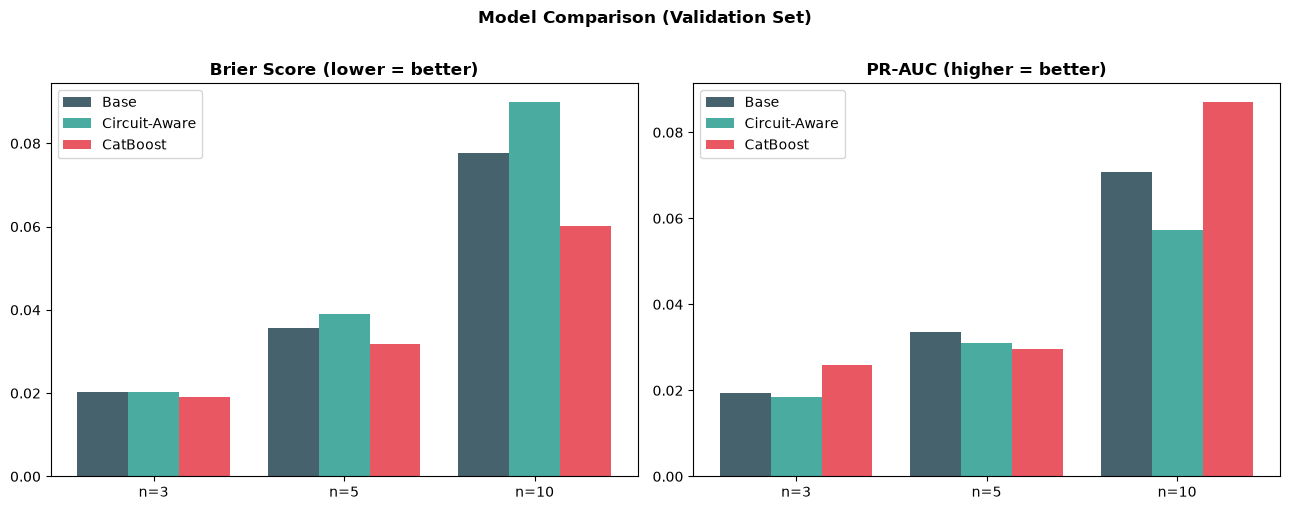

Circuit feature delta (Base -> Circuit-Aware):
  n= 3: Brier -0.0000  PR-AUC -0.0009
  n= 5: Brier -0.0035  PR-AUC -0.0026
  n=10: Brier -0.0122  PR-AUC -0.0136


In [73]:
if metrics_base and metrics_circ:
    h_list = sorted(set(metrics_base) & set(metrics_circ))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    model_sets = [('Base', metrics_base, '#264653'), ('Circuit-Aware', metrics_circ, '#2A9D8F')]
    if CATBOOST_AVAILABLE and metrics_catb:
        model_sets.append(('CatBoost', metrics_catb, '#E63946'))

    for ax, metric, title in zip(
        axes,
        ['brier', 'prauc'],
        ['Brier Score (lower = better)', 'PR-AUC (higher = better)']
    ):
        width = 0.8 / len(model_sets)
        for i, (name, met, col) in enumerate(model_sets):
            vals = [met.get(h, {}).get(metric, 0) for h in h_list]
            x    = [j + i*width for j in range(len(h_list))]
            ax.bar(x, vals, width, label=name, color=col, alpha=0.85)
        ax.set_xticks([j + width for j in range(len(h_list))])
        ax.set_xticklabels([f'n={h}' for h in h_list])
        ax.set_title(title, fontweight='bold')
        ax.legend()

    plt.suptitle('Model Comparison (Validation Set)', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print('Circuit feature delta (Base -> Circuit-Aware):')
    for h in h_list:
        db = metrics_base[h]['brier'] - metrics_circ[h]['brier']
        dp = metrics_circ[h]['prauc'] - metrics_base[h]['prauc']
        print(f'  n={h:>2}: Brier {db:+.4f}  PR-AUC {dp:+.4f}')


---

## 13. Feature Importance (Circuit Features Highlighted)


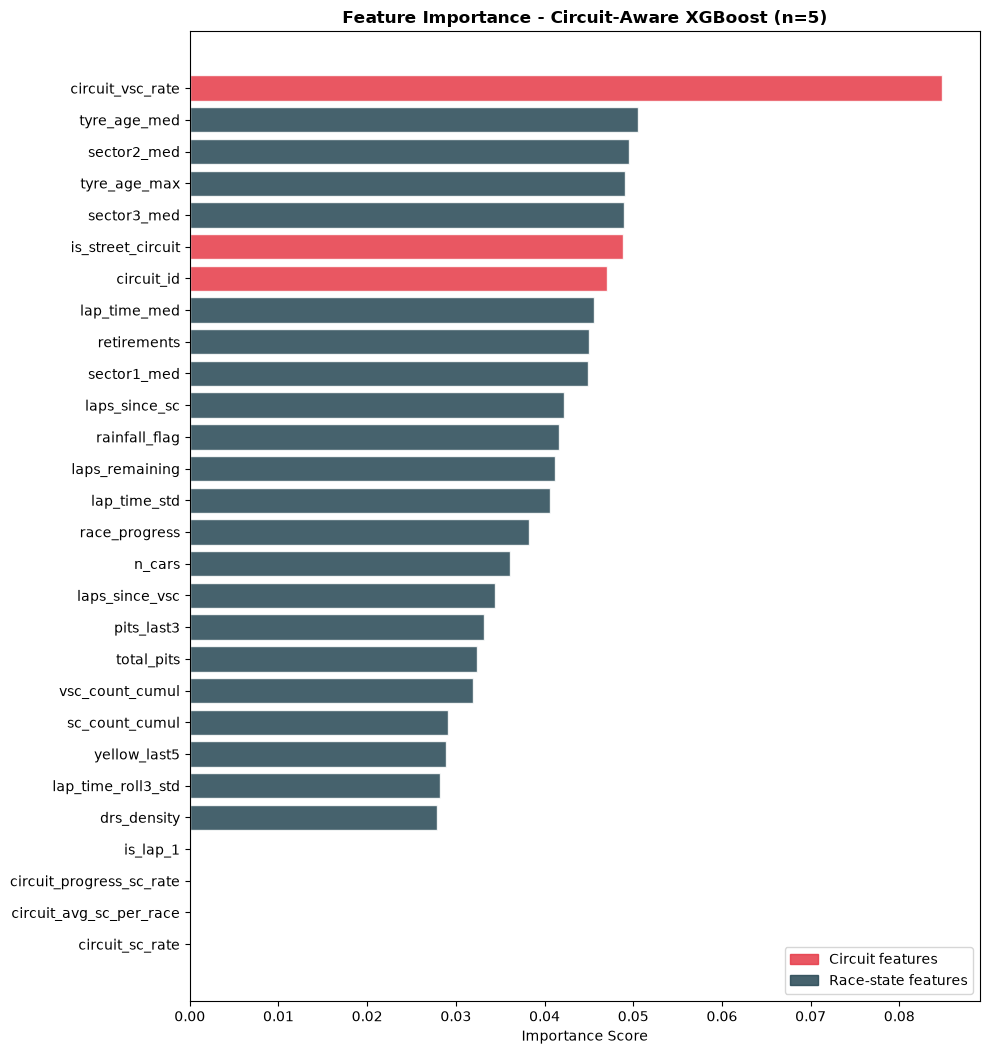

In [74]:
CIRCUIT_FEAT_SET = {
    'is_street_circuit','circuit_id','circuit_sc_rate',
    'circuit_vsc_rate','circuit_avg_sc_per_race','circuit_progress_sc_rate'
}

for n_show in [1, 5]:
    if n_show not in models_circ: continue
    model = models_circ[n_show]
    feats = metrics_circ[n_show]['feats']
    imp   = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=True)

    colors = ['#E63946' if f in CIRCUIT_FEAT_SET else '#264653' for f in imp.index]
    fig, ax = plt.subplots(figsize=(10, max(4, len(imp)*0.38)))
    ax.barh(imp.index, imp.values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(f'Feature Importance - Circuit-Aware XGBoost (n={n_show})', fontweight='bold')
    ax.set_xlabel('Importance Score')
    red_p  = mpatches.Patch(color='#E63946', alpha=0.85, label='Circuit features')
    blue_p = mpatches.Patch(color='#264653', alpha=0.85, label='Race-state features')
    ax.legend(handles=[red_p, blue_p], loc='lower right')
    plt.tight_layout()
    plt.show()


---

## 14. Sequential Race Replay


In [75]:
def hazard_to_probs(hazards, horizons=HORIZONS):
    h = np.clip(np.array(hazards[:max(horizons)], dtype=float), 0, 1)
    cp = 1.0 - np.cumprod(1 - h)
    return {n: float(cp[n-1]) for n in horizons}


def predict(row, models=models_circ, cals=cals_circ, metrics=metrics_circ):
    per_h = {}
    for n in HORIZONS:
        if n not in models:
            per_h[n] = 0.0
            continue
        feats = metrics[n]['feats']
        X     = pd.DataFrame([{f: row.get(f, 0) for f in feats}]).fillna(0)
        raw   = models[n].predict_proba(X)[0, 1]
        per_h[n] = float(cals[n].predict([raw])[0])
    return per_h


def replay_race(race_id, feature_df, model_fn):
    rows = []
    for _, row in feature_df[feature_df['race_id']==race_id].sort_values('LapNumber').iterrows():
        probs  = model_fn(row.to_dict())
        record = {'race_id': race_id, 'LapNumber': row['LapNumber'],
                  'location': row.get('location','')}
        for n in HORIZONS:
            record[f'P_SC_{n}']    = probs.get(n, 0.0)
            record[f'SC_next_{n}'] = row.get(f'SC_next_{n}', np.nan)
        record['next_sc_lap'] = row.get('next_sc_lap', np.nan)
        rows.append(record)
    return pd.DataFrame(rows)


# Abu Dhabi 2021
abu_ids = [r for r in feature_df['race_id'].unique() if 'Abu' in r and '2021' in r]
if abu_ids:
    abu_replay = replay_race(abu_ids[0], feature_df, predict)
    print(f'Replayed: {abu_ids[0]}')
    print(f'Location: {abu_replay["location"].iloc[0]}')
    for n in HORIZONS:
        sub = abu_replay.dropna(subset=[f'SC_next_{n}'])
        if len(sub) < 5: continue
        bs = brier_score_loss(sub[f'SC_next_{n}'].astype(int), sub[f'P_SC_{n}'])
        ap = average_precision_score(sub[f'SC_next_{n}'].astype(int), sub[f'P_SC_{n}'])
        print(f'  n={n:>2}: Brier={bs:.4f}  PR-AUC={ap:.4f}')
else:
    print('Abu Dhabi 2021 not found.')
    print('Available 2021:', [r for r in feature_df['race_id'].unique() if '2021' in r])


Replayed: 2021_Abu_Dhabi_Grand_Prix
Location: Yas Island
  n= 3: Brier=0.0298  PR-AUC=1.0000
  n= 5: Brier=0.0338  PR-AUC=1.0000
  n=10: Brier=0.0225  PR-AUC=1.0000


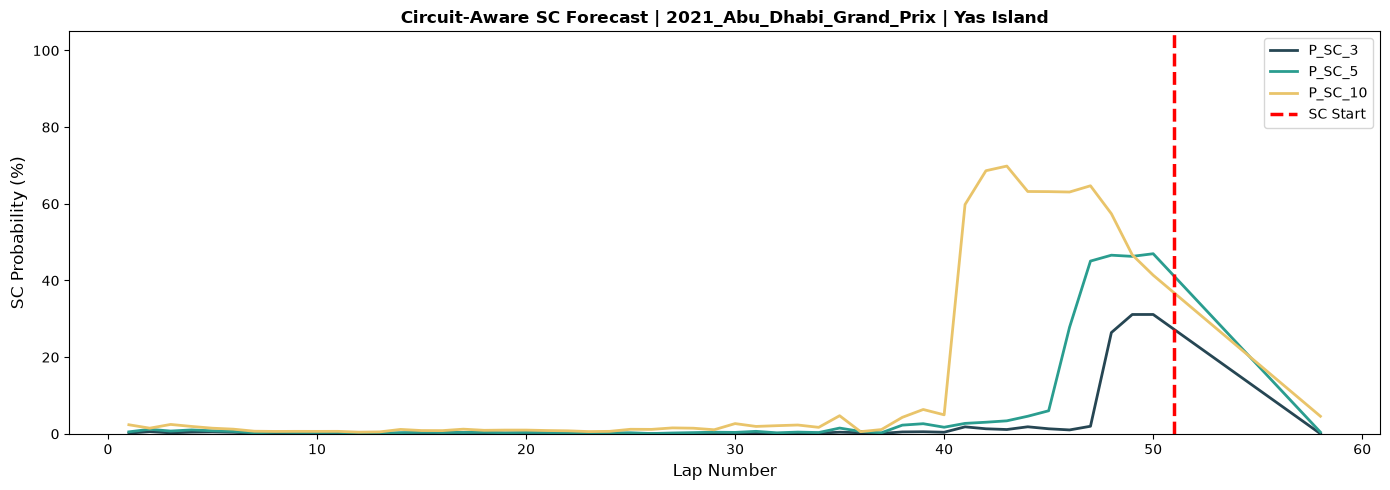

In [76]:
def plot_forecast(replay_df, race_id, df_laps):
    fig, ax = plt.subplots(figsize=(14, 5))
    colors  = ['#264653','#2A9D8F','#E9C46A','#E63946']
    for n, col in zip(HORIZONS, colors):
        ax.plot(replay_df['LapNumber'], replay_df[f'P_SC_{n}']*100,
                label=f'P_SC_{n}', color=col, linewidth=2)
    sc_starts = df_laps[(df_laps['race_id']==race_id)&(df_laps['sc_started']==1)]['LapNumber'].values
    for i, lap in enumerate(sc_starts):
        ax.axvline(lap, color='red', linewidth=2.5, linestyle='--',
                   label='SC Start' if i==0 else '')
    location_name = replay_df['location'].iloc[0] if len(replay_df) else ''
    ax.set_xlabel('Lap Number', fontsize=12)
    ax.set_ylabel('SC Probability (%)', fontsize=12)
    ax.set_title(f'Circuit-Aware SC Forecast | {race_id} | {location_name}',
                 fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()


if abu_ids and 'abu_replay' in dir():
    plot_forecast(abu_replay, abu_ids[0], df_laps)


---

## 15. Summary

### Location over RaceName — why it matters

```
Red Bull Ring races in training data:
  2018 Austrian GP
  2019 Austrian GP
  2020 Austrian GP       <- same physical circuit
  2020 Styrian GP        <- different name, same circuit!
  2021 Austrian GP
  2021 Styrian GP        <- pooled together via Location = 'Spielberg'
  2022 Austrian GP
```

Using `Location` pools all these into one circuit history — ~7 data points instead of ~3-4.
This directly improves the reliability of `circuit_sc_rate` and `circuit_progress_sc_rate`.

### XGBoost categorical fix

- `enable_categorical=True` requires every category in val/test to exist in training
- New venues (e.g. Las Vegas 2023, added mid-dataset) break this requirement
- Fix: integer-encode Location on ALL data (not leakage — just identity mapping)
- XGBoost tree splits on integers naturally, learning circuit-specific thresholds

### Feature summary

| Feature | Source | Leakage-safe? |
|---------|--------|---------------|
| `is_street_circuit` | Domain knowledge | Yes |
| `circuit_id` | All-data label encoding of Location | Yes |
| `circuit_sc_rate` | Training data only, shrunken | Yes |
| `circuit_vsc_rate` | Training data only, shrunken | Yes |
| `circuit_avg_sc_per_race` | Training data only | Yes |
| `circuit_progress_sc_rate` | Training data only, shrunken | Yes |


---

## 16. Ablation: Circuit Identity Only (No Pre-Computed SC Rates)

**Question:** Was the improvement in the circuit-aware model coming from:

- **(A)** The model genuinely learning circuit-specific patterns via `circuit_id`?
- **(B)** Just the Heilmeier baseline (`circuit_sc_rate`, `circuit_progress_sc_rate`) being fed directly as a feature?

To test this, we train a third model with:

- `circuit_id` + `is_street_circuit` — circuit identity and domain knowledge
- **NO** `circuit_sc_rate`, `circuit_vsc_rate`, `circuit_progress_sc_rate`, `circuit_avg_sc_per_race`

The model must learn SC rates from the data itself (via tree splits on `circuit_id`),
rather than being told the pre-computed historical rate.

| Model | Circuit signal | SC rate fed? |
|-------|---------------|-------------|
| Base | None | No |
| Circuit-Aware Full | `circuit_id` + rates + domain | Yes |
| Circuit-ID Only | `circuit_id` + domain | **No** |


In [77]:
# Feature set: circuit identity and domain knowledge ONLY
# No pre-computed historical SC rates of any kind
CIRCUIT_ID_FEATURES = BASE_FEATURES + [
    'circuit_id',           # integer-encoded Location (XGBoost learns its own SC rate)
    'is_street_circuit',    # domain knowledge: street vs permanent
]

models_id, cals_id, metrics_id = {}, {}, {}

print('=== Circuit-ID Only (no pre-computed SC rates) ===')
for n in HORIZONS:
    m, c, met = train_xgb(train_df, val_df, n, CIRCUIT_ID_FEATURES)
    if m:
        models_id[n], cals_id[n], metrics_id[n] = m, c, met
        print(f'  n={n:>2}: Brier={met["brier"]:.4f}  PR-AUC={met["prauc"]:.4f}')


=== Circuit-ID Only (no pre-computed SC rates) ===
  n= 3: Brier=0.0201  PR-AUC=0.0186
  n= 5: Brier=0.0356  PR-AUC=0.0355
  n=10: Brier=0.0831  PR-AUC=0.0740


---

## 17. Three-Way Comparison


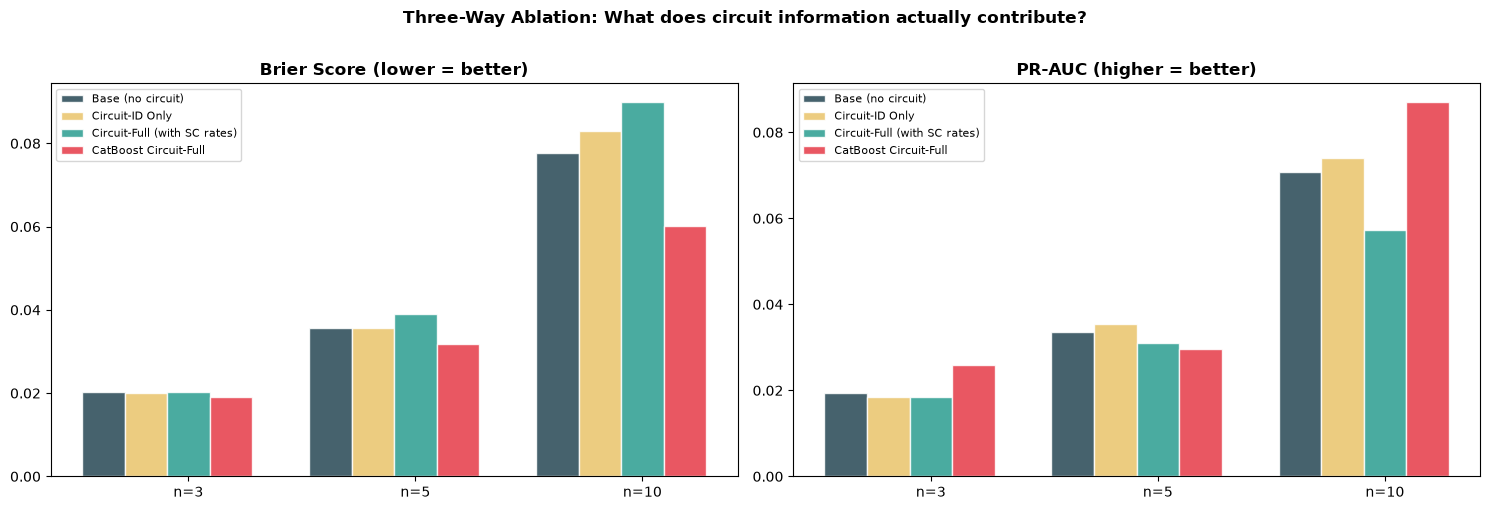

In [78]:
# Three-way comparison: Base vs Circuit-ID-Only vs Circuit-Full
all_models = [
    ('Base (no circuit)',           metrics_base, '#264653'),
    ('Circuit-ID Only',             metrics_id,   '#E9C46A'),
    ('Circuit-Full (with SC rates)', metrics_circ, '#2A9D8F'),
]
if CATBOOST_AVAILABLE and 'metrics_catb' in dir() and metrics_catb:
    all_models.append(('CatBoost Circuit-Full', metrics_catb, '#E63946'))

h_list = HORIZONS
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, title in zip(
    axes,
    ['brier', 'prauc'],
    ['Brier Score (lower = better)', 'PR-AUC (higher = better)']
):
    width = 0.75 / len(all_models)
    for i, (name, met, col) in enumerate(all_models):
        if not met: continue
        vals = [met.get(h, {}).get(metric, 0) for h in h_list]
        x    = [j + i * width for j in range(len(h_list))]
        ax.bar(x, vals, width, label=name, color=col, alpha=0.85, edgecolor='white')
    ax.set_xticks([j + width * len(all_models)/2 for j in range(len(h_list))])
    ax.set_xticklabels([f'n={h}' for h in h_list])
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Three-Way Ablation: What does circuit information actually contribute?',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [79]:
# Tabular summary
print('=== ABLATION RESULTS (Validation Set) ===')
print(f'{"Model":<35} {" ".join(f"n={h:>2}(B)" for h in HORIZONS)}')
for name, met, _ in all_models:
    if not met: continue
    vals = '  '.join(f'{met.get(h,{}).get("brier",float("nan")):.4f}' for h in HORIZONS)
    print(f'{name:<35} {vals}')

print()
print(f'{"Model":<35} {" ".join(f"n={h}(P)" for h in HORIZONS)}')
for name, met, _ in all_models:
    if not met: continue
    vals = '  '.join(f'{met.get(h,{}).get("prauc",float("nan")):.4f}' for h in HORIZONS)
    print(f'{name:<35} {vals}')

print()
print('Interpretation guide:')
print('  If Circuit-ID Only ~ Circuit-Full  -> model learns SC rates from data; rates were redundant')
print('  If Circuit-ID Only ~ Base          -> pre-computed rates were doing all the work')
print('  If Circuit-ID Only is between     -> both contribute independently')


=== ABLATION RESULTS (Validation Set) ===
Model                               n= 3(B) n= 5(B) n=10(B)
Base (no circuit)                   0.0202  0.0356  0.0777
Circuit-ID Only                     0.0201  0.0356  0.0831
Circuit-Full (with SC rates)        0.0202  0.0391  0.0899
CatBoost Circuit-Full               0.0190  0.0319  0.0602

Model                               n=3(P) n=5(P) n=10(P)
Base (no circuit)                   0.0193  0.0336  0.0709
Circuit-ID Only                     0.0186  0.0355  0.0740
Circuit-Full (with SC rates)        0.0184  0.0310  0.0573
CatBoost Circuit-Full               0.0259  0.0297  0.0870

Interpretation guide:
  If Circuit-ID Only ~ Circuit-Full  -> model learns SC rates from data; rates were redundant
  If Circuit-ID Only ~ Base          -> pre-computed rates were doing all the work
  If Circuit-ID Only is between     -> both contribute independently


---

## 18. What the Ablation Tells Us

### Interpreting the results

**If Circuit-ID-Only performance is close to Circuit-Full:**

> XGBoost is learning its own circuit-specific SC rates through tree splits on `circuit_id`.
> The pre-computed `circuit_sc_rate` and `circuit_progress_sc_rate` are largely redundant —
> the model already knows this from the data. The improvement over base is genuine.

**If Circuit-ID-Only performance is close to Base:**

> The pre-computed historical rates were doing all the heavy lifting.
> Essentially we were feeding the model 'the answer' (Heilmeier baseline) as a feature.
> `circuit_id` alone doesn't have enough data per circuit to learn reliable rates.
> (~7 races per circuit = very sparse for a tree to learn stable splits)

**If Circuit-ID-Only is in between:**

> Both signals contribute independently. The pre-computed rates add information
> beyond what the raw circuit identity can learn from limited samples.
> This is the expected outcome with 7 seasons of data.

### The deeper question

Even if pre-computed rates improve validation metrics, they should be
used carefully in production:

- They encode historical circuit character (2018–2022)
- If a circuit undergoes significant changes (new layout, repave, barriers moved),
  the historical rate is no longer accurate
- `circuit_id` + race-state features are more robust to circuit evolution


In [84]:
races_to_test = [
    '2021_Abu_Dhabi_Grand_Prix', 
    '2023_Australian_Grand_Prix', 
    '2023_Bahrain_Grand_Prix', 
    '2022_Monaco_Grand_Prix'
]

for race in races_to_test:
    # Check if the race exists in your aggregated dataset
    if race not in df_laps['race_id'].values:
        print(f"Skipping {race} (not found in dataset)\n")
        continue
        
    print(f"=== Top 5 Highest Risk Laps: {race} ===")
    
    # Run the replay for this specific race
    replay_df = replay_race(race, df_laps, predict)
    
    # Format the probabilities as percentages
    for n in HORIZONS:
        if f'P_SC_{n}' in replay_df.columns:
            replay_df[f'P_SC_{n}'] = (replay_df[f'P_SC_{n}'] * 100).map('{:.1f}%'.format)
            
    # Print the top 5 most dangerous laps (sorted by the 3-lap horizon)
    display_cols = ['LapNumber', 'P_SC_3', 'P_SC_5', 'P_SC_10']
    print(replay_df[display_cols].sort_values('P_SC_3', ascending=False).head(5).to_string(index=False))
    print("\n" + "="*50 + "\n")


=== Top 5 Highest Risk Laps: 2021_Abu_Dhabi_Grand_Prix ===
 LapNumber P_SC_3 P_SC_5 P_SC_10
        45   0.1%   0.2%    2.1%
        50   0.1%   0.3%    2.4%
        16   0.1%   0.1%    0.2%
        47   0.1%   0.4%    2.2%
        48   0.1%   0.5%    1.8%


=== Top 5 Highest Risk Laps: 2023_Australian_Grand_Prix ===
 LapNumber P_SC_3 P_SC_5 P_SC_10
        16   0.1%   0.4%    2.8%
         5   0.1%   0.1%    0.8%
        15   0.1%   0.3%    2.8%
        17   0.1%   0.4%    2.5%
        35   0.0%   0.0%    0.1%


=== Top 5 Highest Risk Laps: 2023_Bahrain_Grand_Prix ===
 LapNumber P_SC_3 P_SC_5 P_SC_10
        40   0.1%   0.2%    0.4%
         1   0.0%   0.0%    0.1%
        30   0.0%   0.0%    0.1%
        32   0.0%   0.0%    0.1%
        33   0.0%   0.0%    0.1%


=== Top 5 Highest Risk Laps: 2022_Monaco_Grand_Prix ===
 LapNumber P_SC_3 P_SC_5 P_SC_10
        22   0.3%   0.4%    2.0%
        21   0.1%   0.3%    3.7%
        23   0.1%   0.1%    0.1%
        24   0.1%   0.1%    0.1%
   